In [1]:
from pathlib import Path
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 
import string
from sklearn.metrics import roc_auc_score, roc_curve

In [2]:
sns.set(font_scale=2)
sns.set_style("darkgrid")
sns.set_palette("Set1")
# plt.rcParams['xtick.major.size'] = 20
plt.rcParams["xtick.major.width"] = 3
plt.rcParams["xtick.bottom"] = True
plt.rcParams["ytick.left"] = True

In [3]:
fig4 = pd.read_csv("fig4.csv")

In [23]:
clf_names = [
    "might",
    "rf",
    "svm",
    "nb",
    "lr",
]

In [5]:
fig4["Variable-Set Type"] = "empty"
types = [["Wise", "icho"], ["Moti"], ["Dyad"], ["Leng", "Delf"], ["Loci"]]
type_names = [
    "Aneuploidy",
    "Fragment End-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]
for i in range(len(fig4)):
    for j in range(len(types)):
        if fig4.iloc[i]["Variable Set"][:4] in types[j]:
            fig4.iat[i, 6] = type_names[j]


fig4 = fig4.sort_values(by="Variable-Set Type")

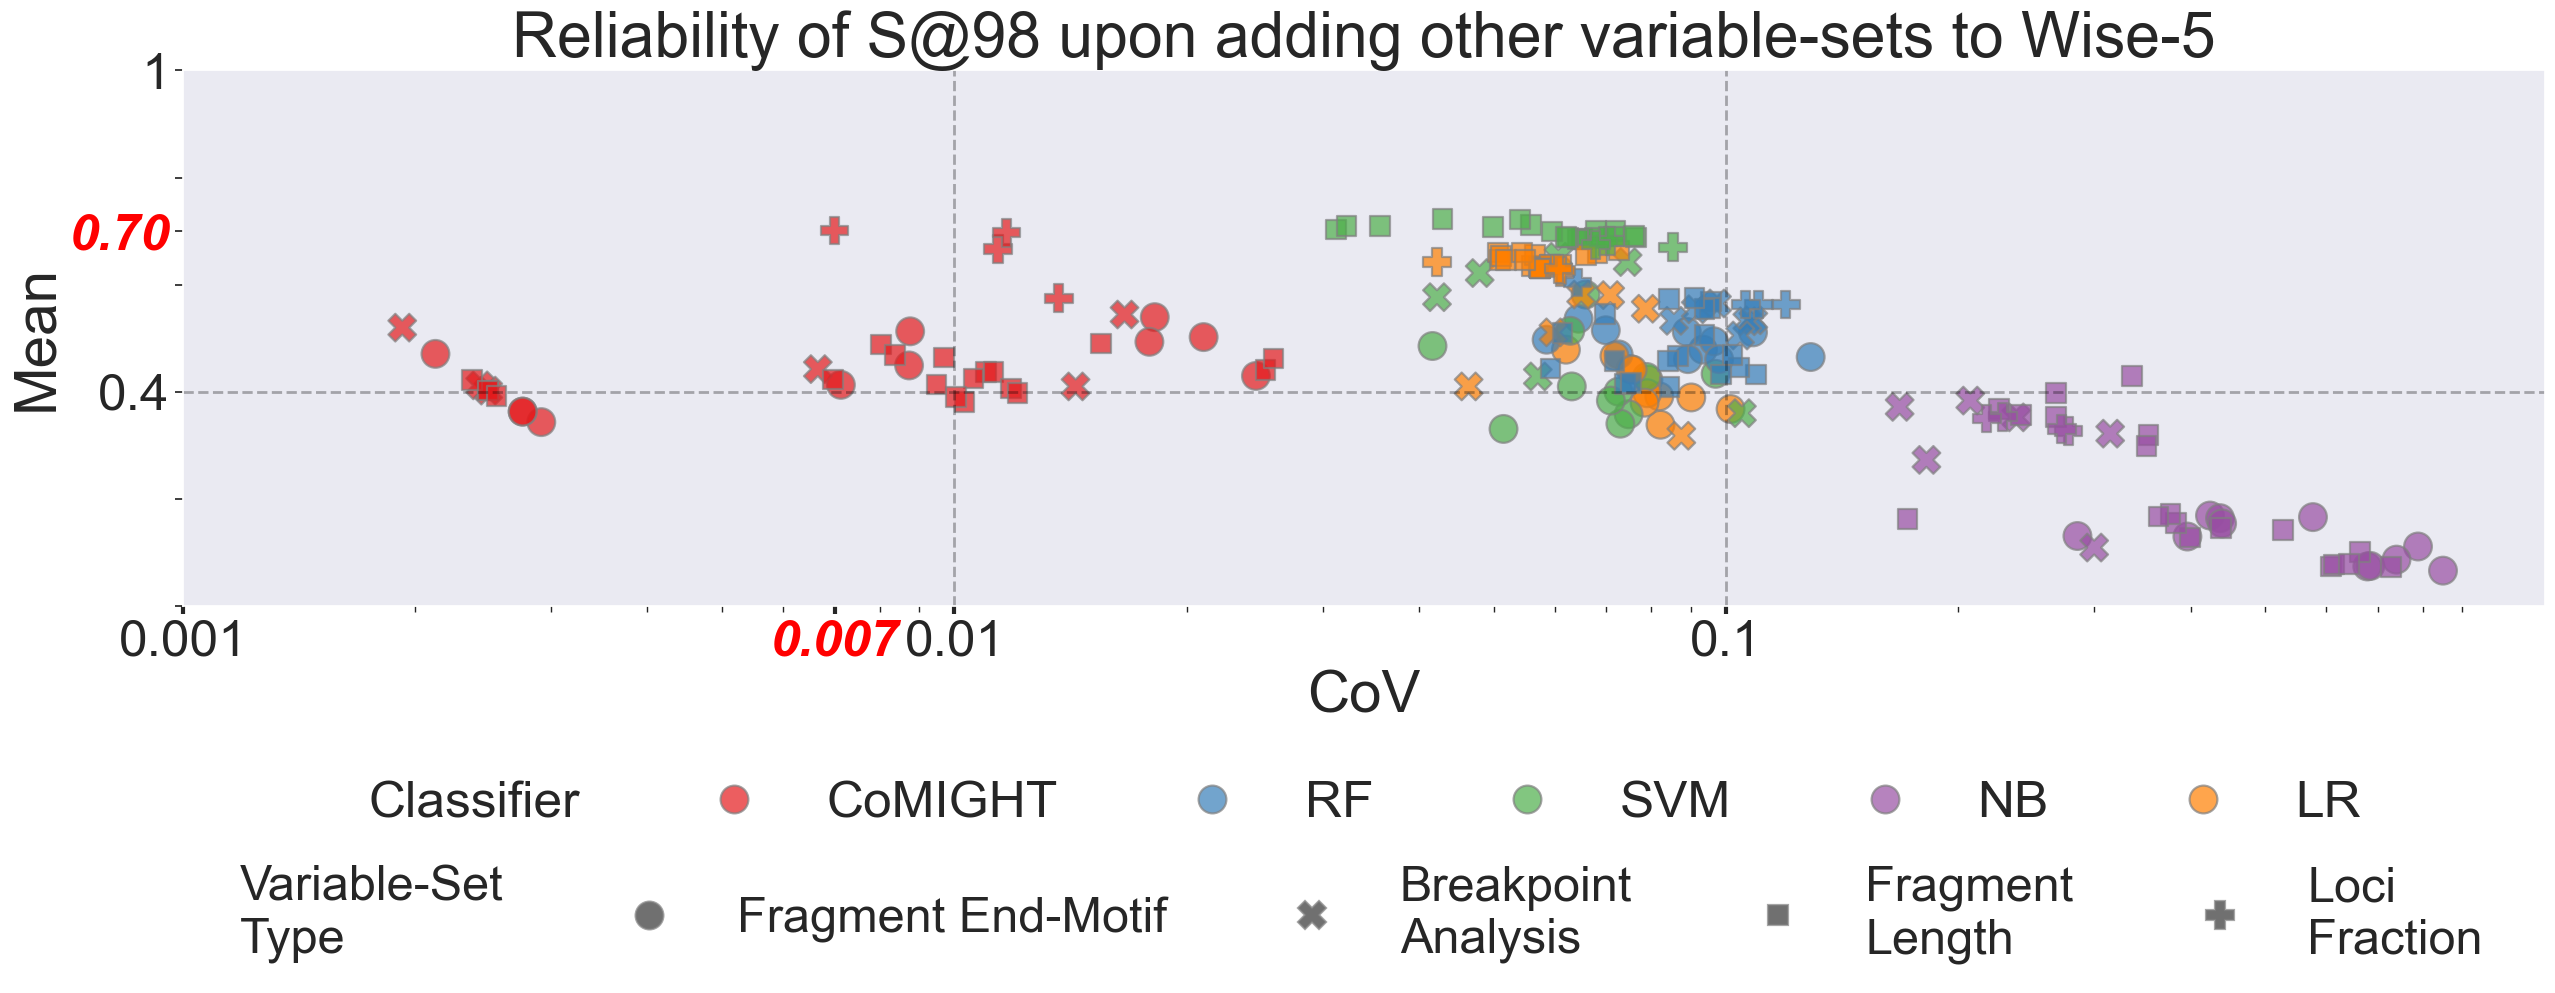

In [25]:
fontsize = 37
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(26, 8), constrained_layout=True)
ax_i = ax
colors = sns.color_palette("Set1", n_colors=10, as_cmap=False)
palette = {
    "might": colors[0],
    "rf": colors[1],
    "svm": colors[2],
    "nb": colors[3],
    "lr": colors[4],
}

g = sns.scatterplot(
    x="CoV",
    y="mean",
    hue="Classifier",
    data=fig4,
    s=400,
    alpha=0.7,
    ax=ax_i,
    palette=palette,
    style="Variable-Set Type",
    edgecolor="grey",
    hue_order=clf_names,
)
empty_labels = ["" for _ in range(fig4.shape[0])]


ax_i.set_ylim([0, 1.0])
ax_i.set_xscale("log")
# ax_i.set_xlim([0,1.0])
# ax_i.xaxis.set_minor_locator(ticker.NullLocator())
ax_i.set_yticks(
    [0, 0.2, 0.4, 0.6, 0.70, 0.8, 1], ["", "", 0.4, "", "0.70", "", 1], fontsize=fontsize
)
for pos in [0.01, 0.1]:
    ax.axvline(x=pos, color="black", linestyle="--", alpha=0.3, lw=2)
ax.axhline(y=0.4, color="black", linestyle="--", alpha=0.3, lw=2)

for tick in ax_i.get_yticklabels():
#     print(tick.get_text())
    if tick.get_text() == "0.70":
        tick.set_color("red")
        tick.set_fontweight("bold")
        tick.set_style("italic")
ax_i.set_ylabel("Mean", fontsize=fontsize + 5)
ax_i.set_xlabel("CoV", fontsize=fontsize + 5)
# ticks = [min_cov,max_cov,max_cov_rf,max_cov_all]
# ticks = [0.001,0.007,0.01,0.03,0.1,1.0]
ticks = [0.001, 0.01, 0.1, 0.007]
ax_i.set_xticks(ticks)
ax_i.set_xticklabels([str(tick) for tick in ticks], fontsize=fontsize)
ax_i.get_xticklabels()[-1].set_fontweight("bold")
ax_i.get_xticklabels()[-1].set_style("italic")
ax_i.get_xticklabels()[-1].set_color("red")
# for tick in ax_i.get_xticklabels():
#     print(tick.get_text())
#     if tick.get_text() == "0.007":
#         tick.set_color("red")
#         tick.set_fontweight("bold")
# for tick in ax_i.get_xticklabels():
#     print(tick.get_text())
#     if tick.get_text() == "0.03":
#         tick.set_color("green")
#         tick.set_fontweight("bold")

ax_i.set_title(
    "Reliability of S@98 upon adding other variable-sets to Wise-5", fontsize=fontsize + 8
)
ax_i.grid(False)
legend_labels = {"rf": "RF", "svm": "SVM", "might": "CoMIGHT", "nb": "NB", "lr": "LR"}


# desired_order = ["might", "rf", "svm", "nb", "lr"]
# handles, labels = plt.gca().get_legend_handles_labels()
# legend_dict = dict(zip(labels, handles))
# reordered_handles = [
#     legend_dict[label] for label in desired_order if label in legend_dict
# ]
# new_labels = [legend_labels[label] for label in desired_order]
# plt.legend(
#     reordered_handles,
#     new_labels,
#     loc="center",
#     bbox_to_anchor=(0.5, -0.3),
#     ncol=len(desired_order),
#     frameon=False,
#     fontsize=fontsize,
# )
handles, labels = ax.get_legend_handles_labels()
hue_labels = fig4["Classifier"].dropna().unique()
style_labels = fig4["Variable-Set Type"].dropna().unique()

hue_handles = handles[: len(hue_labels)+1]
hue_names = labels[: len(hue_labels)+1]
hue_names = [hue_names[0], "CoMIGHT"] + [word.upper() for word in hue_names[2:]]

style_handles = handles[len(hue_labels) +1:]
style_names = [
    "Variable-Set\nType",
    "Fragment End-Motif",
    "Breakpoint\nAnalysis",
    "Fragment\nLength",
    "Loci\nFraction",
]

legend1 = ax.legend(
    handles=hue_handles,
    labels=hue_names,
    loc="lower center",
    bbox_to_anchor=(0.47, -0.5),
    frameon=False,
    ncol=len(hue_names),
    fontsize=fontsize,
)

# Second legend (sex/style)
legend2 = ax.legend(
    handles=style_handles,
    labels=style_names,  # title='Variable-Set Type',
    loc="lower center",
    bbox_to_anchor=(0.47, -0.75),
    frameon=False,
    ncol=len(style_names),
    fontsize=fontsize-2,
)

# Add back the first legend manually
ax_i.add_artist(legend1)

plt.show()